# 02 — Simple Buy-and-Hold

**Goal:** measure the plain buy-and-hold S&P 500 strategy properly. Every later strategy is judged against this baseline, so we need to know exactly what 'just hold the index' delivers.

We compute, and explain, each statistic:
- **CAGR** — the constant yearly growth rate that links start to end.
- **Volatility** — annualized standard deviation of daily returns.
- **Sharpe** — excess return per unit of total volatility.
- **Sortino** — like Sharpe but only penalizes *downside* moves.
- **Max drawdown** — worst peak-to-trough fall.
- **Calmar** — CAGR ÷ |max drawdown| (return per unit of pain).

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import data_loader as dl, returns as rt, backtest as bt
from src import metrics as mx, plots as pl

underlying, ticker, source = dl.get_underlying_total_return()
u = rt.simple_returns(underlying)
rf = dl.get_risk_free_daily(u.index)   # daily T-bill return for Sharpe
print('Loaded', ticker, len(u), 'daily returns')

Loaded ^SP500TR 9679 daily returns


## Run buy-and-hold and summarise it

The backtester treats buy-and-hold as 'exposure = 1.0 every day'. The `summary()` method returns every statistic in one dict.

In [3]:
bh = bt.buy_and_hold(u, rf_daily=rf, name='Buy & Hold S&P 500 TR')
s = bh.summary(rf_daily=rf)
import pandas as pd
pd.Series(s)

name                   Buy & Hold S&P 500 TR
start                    1988-01-05 00:00:00
end                      2026-06-08 00:00:00
n_days                                  9679
years                                38.4087
total_return                         63.6582
cagr                                  0.1147
volatility                            0.1787
sharpe                                0.5356
sortino                               0.7566
max_drawdown                         -0.5525
calmar                                0.2075
worst_day                            -0.1198
best_day                              0.1158
worst_month                          -0.1680
best_month                            0.1282
pct_positive_days                     0.5449
pct_positive_months                   0.6602
n_switches                                 0
dtype: object

## What the numbers say

Read off the CAGR, volatility, Sharpe and — most importantly — the **maximum drawdown**. Buy-and-hold compounds nicely over decades, but it also lived through losing more than half its value (2000–02 and 2007–09). That pain is the thing every 'improvement' in this project is trying to reduce.

In [4]:
metrics_we_care_about = ['cagr','volatility','sharpe','sortino',
    'max_drawdown','calmar','worst_day','best_day','worst_month',
    'best_month','pct_positive_days','pct_positive_months']
pd.Series({k: s[k] for k in metrics_we_care_about})

cagr                   0.1147
volatility             0.1787
sharpe                 0.5356
sortino                0.7566
max_drawdown          -0.5525
calmar                 0.2075
worst_day             -0.1198
best_day               0.1158
worst_month           -0.1680
best_month             0.1282
pct_positive_days      0.5449
pct_positive_months    0.6602
dtype: float64

## The drawdown chart

Drawdown = how far below the previous high-water mark we are, at every point in time. It is the single most intuitive picture of risk.

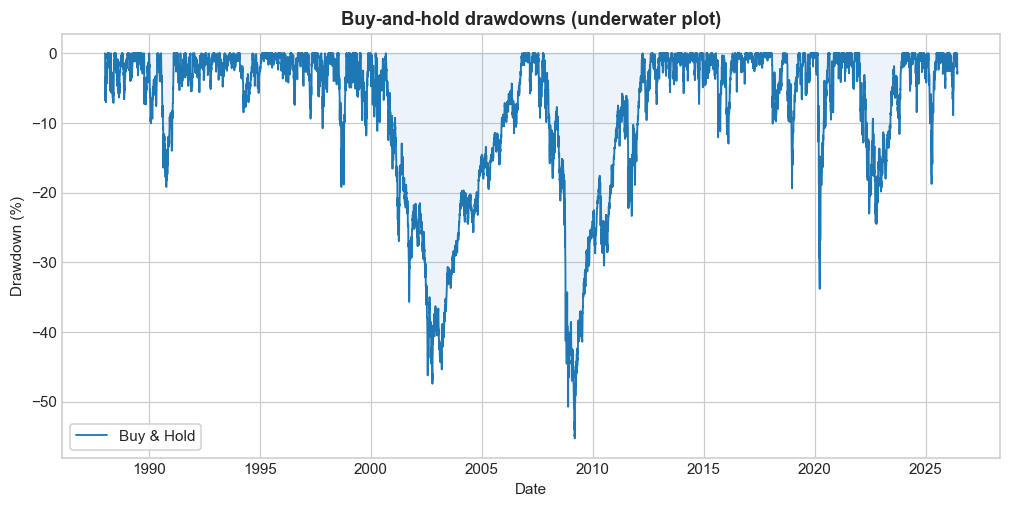

In [5]:
fig = pl.plot_drawdowns({'Buy & Hold': bh.net_returns},
    'Buy-and-hold drawdowns (underwater plot)', '02_bh_drawdown.png',
    colors={'Buy & Hold': '#1f77b4'})
plt.show()

➡️ **Next:** notebook 03 adds the classic Faber-style moving-average rule that tries to dodge the worst of those drawdowns by moving to cash.